# Gaming a two-criterion selective admissions system

This notebook extends the one-stage Simulation lab to writeup §§1–5: underlying types $(00,01,10,11)$, university value $v=(1-w)a+wd$, and tutoring thresholds $S_d$. The writeup is authoritative. Every reported equilibrium and outcome is generated by the tested `admissions_simulation` engine; the finite-population section is validation, not a separate equilibrium concept.

The notebook follows the approved **Simulation lab** flow: declare one parameter source, show every equilibrium, select only the locally stable equilibrium with largest population tutoring mass for comparative statics, report distinct outcome concepts, and then check finite-population convergence. Nested $w=0$ recovery cites `one_stage_admissions_simulation.ipynb` as the Figure 1 exhibit and does not redraw $\beta(S)$ against the 45-degree line.


In [1]:
import math

import matplotlib.pyplot as plt

from admissions_simulation import (
    UniformCostDistribution,
    analyze_scenario,
    analyze_two_criterion_scenario,
    evaluate_threshold_pair,
    one_stage_image,
    run_monte_carlo_validation,
    run_two_criterion_monte_carlo_validation,
    TwoCriterionScenario,
)

plt.style.use('seaborn-v0_8-whitegrid')


## Authoritative parameters

One population, one quota pair, three diversity weights. The benefit of admission and upper tutoring-cost support are both $B=1$; costs are uniform, so $F(c)=c/B$. Underlying shares are $\lambda_{00}=0.448$, $\lambda_{01}=0.252$, $\lambda_{10}=0.192$, $\lambda_{11}=0.108$. These give $D_1=0.36$, equal high-ability odds, and $\lambda_{10}+\lambda_{11}=0.3$. Quotas are $Q\in\{0.33,0.40\}$, so $0.33<D_1<0.40$. Diversity weights are $w\in\{0,\ 1/4,\ 3/4\}$.

| $w$ | role | what the two quotas show |
|---|---|---|
| $0$ | nested | Figure 1 recovery in `one_stage_admissions_simulation.ipynb` |
| $1/4$ | mixed tight-quota | $\mu_{10}=\mu_{11}$, $C_0-C_1=1/3$, both selected $S_d$ rise with $Q$ |
| $3/4$ | stratified | ranking $\mu_{11}>\mu_{01}>\mu_{10}>\mu_{00}$; $Q=0.33$ competes in $d=1$ ($S_0=0$); $Q=0.40$ competes in $d=0$ ($S_1=0$) |

Selection among isolated locally stable roots is the largest population tutoring mass. Mixed reachability $w\lambda_{11}\le(1-2w)\lambda_{01}$ is a parameter check, not an exhibit.


In [2]:
B = 1.0
SHARE_00 = 0.448
SHARE_01 = 0.252
SHARE_10 = 0.192
SHARE_11 = 0.108
QUOTAS = (0.33, 0.40)
WEIGHTS = (0.0, 0.25, 0.75)
COST_DISTRIBUTION = UniformCostDistribution(upper=B)
SELECTION_RULE = 'largest locally stable by population tutoring mass'

def scenario_for(diversity_weight, university_quota):
    return TwoCriterionScenario(
        benefit=B,
        university_quota=university_quota,
        diversity_weight=diversity_weight,
        underlying_share_00=SHARE_00,
        underlying_share_01=SHARE_01,
        underlying_share_10=SHARE_10,
        underlying_share_11=SHARE_11,
    )

analyses = {
    (weight, quota): analyze_two_criterion_scenario(
        scenario_for(weight, quota), COST_DISTRIBUTION
    )
    for weight in WEIGHTS
    for quota in QUOTAS
}

mixed_weight = 0.25
mixed_left = mixed_weight * SHARE_11
mixed_right = (1.0 - 2.0 * mixed_weight) * SHARE_01
print(
    f'B={B:g}, D1={SHARE_01 + SHARE_11:g}, F(c)=c/B, selection={SELECTION_RULE}'
)
print(f'mixed reachability at w=1/4: {mixed_left:g} <= {mixed_right:g}')


B=1, D1=0.36, F(c)=c/B, selection=largest locally stable by population tutoring mass
mixed reachability at w=1/4: 0.027 <= 0.126


## Metric definitions

These quantities are deliberately kept separate. Regime and stability are equilibrium labels, not metrics.

- **Tutoring threshold $S_d$**: the tutoring cost at which a student with diversity dimension $d$ is indifferent.
- **Tutoring participation rate $F(S_d)$**: the share of students with diversity dimension $d$ and underlying $a=0$ who tutor.
- **Population tutoring mass $\lambda_{00}F(S_0)+\lambda_{01}F(S_1)$**: the population share that tutors.
- **Admission probabilities $x_{ad}$**: admission conditional on the observed type.
- **Credibility $C_d$**: the share of the observed high-academic group with diversity dimension $d$ whose underlying $a$ is 1.
- **Posterior evaluation $\mu_{ad}$**: the university's expected university value of an applicant observed as $(a,d)$.
- **Admitted high-ability share**: underlying $a=1$ students as a share of the admitted class.
- **Admitted diversity share**: underlying $d=1$ students as a share of the admitted class.
- **Aggregate tutoring expenditure**: total tutoring costs paid across the population, not a participation measure.


In [3]:
EQUILIBRIUM_COLUMNS = (
    'w', 'Q', 'branch', 'selected', 'S0', 'S1', 'F(S0)', 'F(S1)', 'mass',
    'regime', 'stability', 'x00', 'x01', 'x10', 'x11', 'C0', 'C1',
    'mu00', 'mu01', 'mu10', 'mu11', 'admitted a=1', 'admitted d=1',
    'expenditure',
)

def print_table(columns, rows):
    widths = [
        max(len(str(value)) for value in (column, *(row[i] for row in rows)))
        for i, column in enumerate(columns)
    ]
    def line(row):
        return ' | '.join(str(value).ljust(width) for value, width in zip(row, widths))
    print(line(columns))
    print('-+-'.join('-' * width for width in widths))
    for row in rows:
        print(line(row))

def fmt(value):
    return f'{value:.6f}'

def outcome_cells(outcomes):
    return (
        fmt(outcomes.tutoring_threshold_0),
        fmt(outcomes.tutoring_threshold_1),
        fmt(outcomes.tutoring_participation_rate_0),
        fmt(outcomes.tutoring_participation_rate_1),
        fmt(outcomes.population_tutoring_mass),
    )

def metric_cells(outcomes):
    return (
        fmt(outcomes.admission_probability_00),
        fmt(outcomes.admission_probability_01),
        fmt(outcomes.admission_probability_10),
        fmt(outcomes.admission_probability_11),
        fmt(outcomes.credibility_0),
        fmt(outcomes.credibility_1),
        fmt(outcomes.posterior_evaluation_00),
        fmt(outcomes.posterior_evaluation_01),
        fmt(outcomes.posterior_evaluation_10),
        fmt(outcomes.posterior_evaluation_11),
        fmt(outcomes.admitted_high_ability_share),
        fmt(outcomes.admitted_diversity_share),
        fmt(outcomes.aggregate_tutoring_expenditure),
    )

def equilibrium_row(weight, quota, branch, analysis, equilibrium):
    outcomes = equilibrium.outcomes
    return (
        f'{weight:g}', f'{quota:.2f}', str(branch),
        'yes' if equilibrium is analysis.selected_equilibrium else '',
        *outcome_cells(outcomes),
        equilibrium.regime.value,
        equilibrium.stability.value,
        *metric_cells(outcomes),
    )


## Nested $w=0$ recovery

Figure 1 lives in `one_stage_admissions_simulation.ipynb`. This section does not redraw $\beta(S)$ against the 45-degree line. It prints selected two-criterion outcomes at $w=0$, $Q\in\{0.33,0.40\}$ against the nested identities and against `analyze_scenario` on `one_stage_image`.

At $Q=0.40$ the identities are $S^*=X=F(S^*)=4/7$, population tutoring mass $0.4$, $Y=0$, credibility $=$ admitted high-ability share $=3/7$, expenditure $4/35$. At $Q=0.33$, $S^*=(-0.3+\sqrt{1.014})/1.4$.


In [4]:
NESTED_COLUMNS = (
    'Q', 'source', 'S0 / S*', 'S1', 'F', 'mass', 'x10 / X', 'x00 / Y',
    'credibility', 'admitted a=1', 'expenditure',
)

def nested_identity_row(quota):
    cutoff = 4 / 7 if math.isclose(quota, 0.40) else (-0.3 + math.sqrt(1.014)) / 1.4
    mass = 0.7 * cutoff
    credibility = 0.3 / (0.3 + mass)
    return (
        cutoff, cutoff, cutoff, mass, cutoff, 0.0, credibility,
        0.3 * cutoff / quota, 0.7 * cutoff ** 2 / 2.0,
    )

nested_rows = []
for quota in QUOTAS:
    selected = analyses[0.0, quota].selected_equilibrium
    one_stage = analyze_scenario(
        one_stage_image(scenario_for(0.0, quota)), COST_DISTRIBUTION
    ).selected_equilibrium
    sources = (
        (
            'two-criterion',
            selected.outcomes.tutoring_threshold_0,
            selected.outcomes.tutoring_threshold_1,
            selected.outcomes.tutoring_participation_rate_0,
            selected.outcomes.population_tutoring_mass,
            selected.outcomes.admission_probability_10,
            selected.outcomes.admission_probability_00,
            selected.outcomes.credibility_0,
            selected.outcomes.admitted_high_ability_share,
            selected.outcomes.aggregate_tutoring_expenditure,
        ),
        (
            'one-stage image',
            one_stage.tutoring_cost_cutoff,
            one_stage.tutoring_cost_cutoff,
            one_stage.outcomes.low_ability_tutoring_participation_rate,
            one_stage.outcomes.population_tutoring_mass,
            one_stage.high_score_admission_probability,
            one_stage.low_score_admission_probability,
            one_stage.outcomes.credibility,
            one_stage.outcomes.admitted_high_ability_share,
            one_stage.outcomes.aggregate_tutoring_expenditure,
        ),
        ('§5.1 identity', *nested_identity_row(quota)),
    )
    for source, *values in sources:
        nested_rows.append((f'{quota:.2f}', source, *(fmt(value) for value in values)))
print_table(NESTED_COLUMNS, nested_rows)


Q    | source          | S0 / S*  | S1       | F        | mass     | x10 / X  | x00 / Y  | credibility | admitted a=1 | expenditure
-----+-----------------+----------+----------+----------+----------+----------+----------+-------------+--------------+------------
0.33 | two-criterion   | 0.504983 | 0.504983 | 0.504983 | 0.353488 | 0.504983 | 0.000000 | 0.459075    | 0.459075     | 0.089253   
0.33 | one-stage image | 0.504983 | 0.504983 | 0.504983 | 0.353488 | 0.504983 | 0.000000 | 0.459075    | 0.459075     | 0.089253   
0.33 | §5.1 identity   | 0.504983 | 0.504983 | 0.504983 | 0.353488 | 0.504983 | 0.000000 | 0.459075    | 0.459075     | 0.089253   
0.40 | two-criterion   | 0.571429 | 0.571429 | 0.571429 | 0.400000 | 0.571429 | 0.000000 | 0.428571    | 0.428571     | 0.114286   
0.40 | one-stage image | 0.571429 | 0.571429 | 0.571429 | 0.400000 | 0.571429 | 0.000000 | 0.428571    | 0.428571     | 0.114286   
0.40 | §5.1 identity   | 0.571429 | 0.571429 | 0.571429 | 0.400000 | 0.57142

## Every equilibrium

One table of all six $(w,Q)$ points. Every isolated branch is a row; the selected locally stable equilibrium is marked. $S_d=0$ before-columns are not rows here; they live in the stratified and mixed exhibits.


In [5]:
every_rows = []
for weight in WEIGHTS:
    for quota in QUOTAS:
        analysis = analyses[weight, quota]
        for branch, equilibrium in enumerate(analysis.equilibria, start=1):
            every_rows.append(
                equilibrium_row(weight, quota, branch, analysis, equilibrium)
            )
print_table(EQUILIBRIUM_COLUMNS, every_rows)


w    | Q    | branch | selected | S0       | S1       | F(S0)    | F(S1)    | mass     | regime | stability | x00      | x01      | x10      | x11      | C0       | C1       | mu00     | mu01     | mu10     | mu11     | admitted a=1 | admitted d=1 | expenditure
-----+------+--------+----------+----------+----------+----------+----------+----------+--------+-----------+----------+----------+----------+----------+----------+----------+----------+----------+----------+----------+--------------+--------------+------------
0    | 0.33 | 1      | yes      | 0.504983 | 0.504983 | 0.504983 | 0.504983 | 0.353488 | tight  | stable    | 0.000000 | 0.000000 | 0.504983 | 0.504983 | 0.459075 | 0.459075 | 0.000000 | 0.000000 | 0.459075 | 0.459075 | 0.459075     | 0.360000     | 0.089253   
0    | 0.40 | 1      | yes      | 0.571429 | 0.571429 | 0.571429 | 0.571429 | 0.400000 | tight  | stable    | 0.000000 | 0.000000 | 0.571429 | 0.571429 | 0.428571 | 0.428571 | 0.000000 | 0.000000 | 0.428571 | 0.428

## Stratified rat race

Required exhibit at $w=3/4$. The ranking $\mu_{11}>\mu_{01}>\mu_{10}>\mu_{00}$ is tutoring-independent: it holds at $S_d=0$ (via `evaluate_threshold_pair`) and at the selected equilibrium. With quotas on opposite sides of $D_1=0.36$, the non-marginal group's tutoring threshold is 0 and the marginal group's is positive.

Diversity changes who competes rather than eliminating competition.


Q    | column   | S0       | S1       | mu00     | mu01     | mu10     | mu11     | ranking    
-----+----------+----------+----------+----------+----------+----------+----------+------------
0.33 | S=0      | 0.000000 | 0.000000 | 0.000000 | 0.750000 | 0.250000 | 1.000000 | 11>01>10>00
0.33 | selected | 0.000000 | 0.949949 | 0.000000 | 0.750000 | 0.250000 | 0.827723 | 11>01>10>00
0.40 | S=0      | 0.000000 | 0.000000 | 0.000000 | 0.750000 | 0.250000 | 1.000000 | 11>01>10>00
0.40 | selected | 0.153415 | 0.000000 | 0.000000 | 0.750000 | 0.184098 | 1.000000 | 11>01>10>00


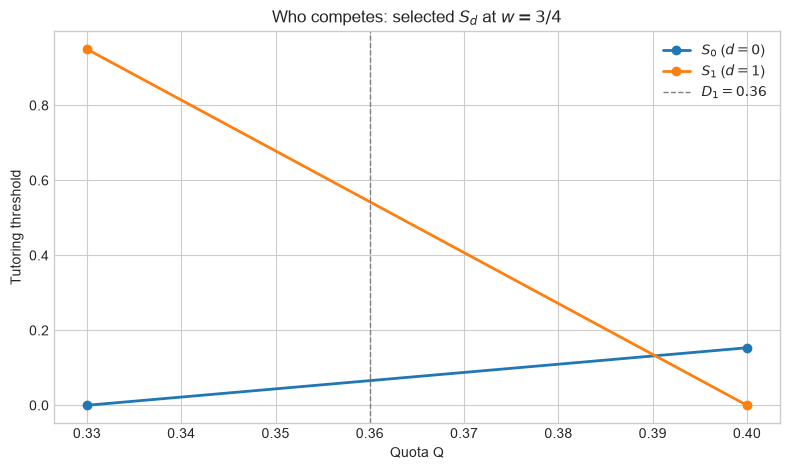

In [6]:
STRATIFIED_COLUMNS = (
    'Q', 'column', 'S0', 'S1', 'mu00', 'mu01', 'mu10', 'mu11', 'ranking',
)

def ranking_label(outcomes):
    ordered = sorted(
        (
            ('00', outcomes.posterior_evaluation_00),
            ('01', outcomes.posterior_evaluation_01),
            ('10', outcomes.posterior_evaluation_10),
            ('11', outcomes.posterior_evaluation_11),
        ),
        key=lambda item: (-item[1], item[0]),
    )
    parts = [ordered[0][0]]
    for previous, current in zip(ordered, ordered[1:]):
        symbol = '=' if abs(previous[1] - current[1]) <= 1e-9 else '>'
        parts.append(symbol + current[0])
    return ''.join(parts)

stratified_rows = []
for quota in QUOTAS:
    scenario = scenario_for(0.75, quota)
    before = evaluate_threshold_pair(scenario, COST_DISTRIBUTION, 0.0, 0.0)
    selected = analyses[0.75, quota].selected_equilibrium.outcomes
    for label, outcomes in (('S=0', before), ('selected', selected)):
        stratified_rows.append((
            f'{quota:.2f}', label, fmt(outcomes.tutoring_threshold_0),
            fmt(outcomes.tutoring_threshold_1),
            fmt(outcomes.posterior_evaluation_00),
            fmt(outcomes.posterior_evaluation_01),
            fmt(outcomes.posterior_evaluation_10),
            fmt(outcomes.posterior_evaluation_11),
            ranking_label(outcomes),
        ))
print_table(STRATIFIED_COLUMNS, stratified_rows)

figure, axis = plt.subplots(figsize=(8, 4.8))
selected_points = [
    analyses[0.75, quota].selected_equilibrium.outcomes for quota in QUOTAS
]
axis.plot(
    QUOTAS, [outcomes.tutoring_threshold_0 for outcomes in selected_points],
    marker='o', linewidth=2, label='$S_0$ ($d=0$)',
)
axis.plot(
    QUOTAS, [outcomes.tutoring_threshold_1 for outcomes in selected_points],
    marker='o', linewidth=2, label='$S_1$ ($d=1$)',
)
axis.axvline(0.36, color='0.5', linestyle='--', linewidth=1, label='$D_1=0.36$')
axis.set(
    xlabel='Quota Q', ylabel='Tutoring threshold',
    title='Who competes: selected $S_d$ at $w=3/4$',
)
axis.legend()
figure.tight_layout()
plt.show()


## Mixed tight-quota

Required exhibit at $w=1/4$. The before-column at $S_d=0$ has ranking $\mu_{11}>\mu_{10}>\mu_{01}>\mu_{00}$. The selected mixed tight-quota equilibrium satisfies $\mu_{10}=\mu_{11}$ and $C_0-C_1=w/(1-w)=1/3$: the diversity premium equals the additional gaming-induced credibility loss. At the larger quota both selected tutoring thresholds are higher.


Q    | column   | S0       | S1       | C0       | C1       | C0-C1    | mu10     | mu11     | ranking    
-----+----------+----------+----------+----------+----------+----------+----------+----------+------------
0.33 | S=0      | 0.000000 | 0.000000 | 1.000000 | 1.000000 | 0.000000 | 0.750000 | 1.000000 | 11>10>01>00
0.33 | selected | 0.210537 | 0.842233 | 0.670577 | 0.337244 | 0.333333 | 0.502933 | 0.502933 | 10=11>01>00
0.40 | S=0      | 0.000000 | 0.000000 | 1.000000 | 1.000000 | 0.000000 | 0.750000 | 1.000000 | 11>10>01>00
0.40 | selected | 0.236495 | 0.949159 | 0.644404 | 0.311071 | 0.333333 | 0.483303 | 0.483303 | 10=11>01>00
identity C0-C1 = w/(1-w) = 0.333333


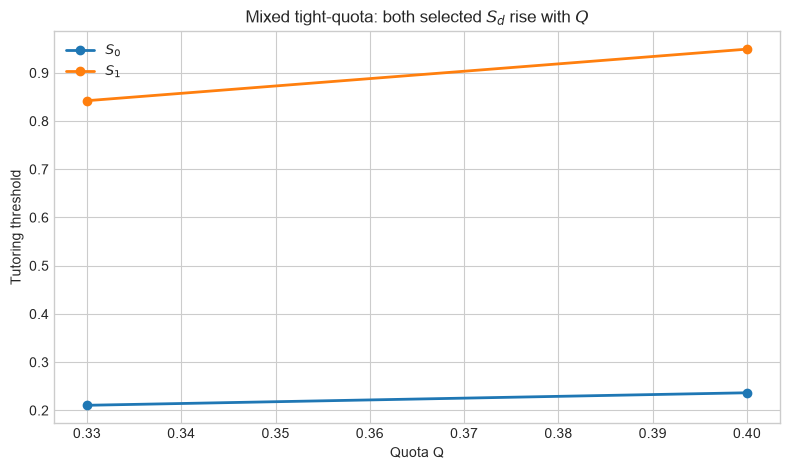

In [7]:
MIXED_COLUMNS = (
    'Q', 'column', 'S0', 'S1', 'C0', 'C1', 'C0-C1', 'mu10', 'mu11', 'ranking',
)

mixed_rows = []
for quota in QUOTAS:
    scenario = scenario_for(0.25, quota)
    before = evaluate_threshold_pair(scenario, COST_DISTRIBUTION, 0.0, 0.0)
    selected = analyses[0.25, quota].selected_equilibrium.outcomes
    for label, outcomes in (('S=0', before), ('selected', selected)):
        mixed_rows.append((
            f'{quota:.2f}', label, fmt(outcomes.tutoring_threshold_0),
            fmt(outcomes.tutoring_threshold_1),
            fmt(outcomes.credibility_0), fmt(outcomes.credibility_1),
            fmt(outcomes.credibility_0 - outcomes.credibility_1),
            fmt(outcomes.posterior_evaluation_10),
            fmt(outcomes.posterior_evaluation_11),
            ranking_label(outcomes),
        ))
print_table(MIXED_COLUMNS, mixed_rows)
print('identity C0-C1 = w/(1-w) =', fmt(0.25 / 0.75))

figure, axis = plt.subplots(figsize=(8, 4.8))
selected_points = [
    analyses[0.25, quota].selected_equilibrium.outcomes for quota in QUOTAS
]
axis.plot(
    QUOTAS, [outcomes.tutoring_threshold_0 for outcomes in selected_points],
    marker='o', linewidth=2, label='$S_0$',
)
axis.plot(
    QUOTAS, [outcomes.tutoring_threshold_1 for outcomes in selected_points],
    marker='o', linewidth=2, label='$S_1$',
)
axis.set(
    xlabel='Quota Q', ylabel='Tutoring threshold',
    title='Mixed tight-quota: both selected $S_d$ rise with $Q$',
)
axis.legend()
figure.tight_layout()
plt.show()


## Finite-population validation

Each seeded finite-population realization samples tutoring costs around the **selected continuum pair** while holding all four $\lambda_{ad}N$ and $QN$ at exact integer counts. The continuum result remains authoritative. Falling RMSE as $N$ grows is evidence that the sampled realization converges toward it; it does not define a finite-population equilibrium. Nested $w=0$ recovers the existing `run_monte_carlo_validation` metrics as images, not the RNG stream.

$N=100$ is illegal on this grid. Increase `MC_TRIALS` for publication runs. The default is intentionally modest so a clean notebook run remains quick.


In [8]:
MC_POPULATION_SIZES = (500, 1000)
MC_TRIALS = 25
MC_SEED = 1729

validation_results = {
    (weight, quota): run_two_criterion_monte_carlo_validation(
        scenario_for(weight, quota),
        COST_DISTRIBUTION,
        population_sizes=MC_POPULATION_SIZES,
        trials=MC_TRIALS,
        seed=MC_SEED,
    )
    for weight in WEIGHTS
    for quota in QUOTAS
}

validation_columns = (
    'w', 'Q', 'N', 'trials', 'regime agreement',
    'S0 RMSE', 'S1 RMSE', 'mass RMSE',
)
validation_rows = []
for (weight, quota), validation in validation_results.items():
    for summary in validation.population_summaries:
        validation_rows.append((
            f'{weight:g}', f'{quota:.2f}', str(summary.population_size),
            str(summary.trials), f'{summary.regime_agreement_rate:.3f}',
            f'{summary.tutoring_threshold_0.root_mean_squared_error:.6f}',
            f'{summary.tutoring_threshold_1.root_mean_squared_error:.6f}',
            f'{summary.population_tutoring_mass.root_mean_squared_error:.6f}',
        ))
print_table(validation_columns, validation_rows)

nested_one_stage = run_monte_carlo_validation(
    one_stage_image(scenario_for(0.0, 0.40)),
    COST_DISTRIBUTION,
    population_sizes=MC_POPULATION_SIZES,
    trials=MC_TRIALS,
    seed=MC_SEED,
)
nested_two = validation_results[0.0, 0.40]
two_continuum = nested_two.continuum_equilibrium.outcomes
one_continuum = nested_one_stage.continuum_equilibrium
print('nested w=0 Q=0.40 continuum targets (images, not the RNG stream)')
image_columns = ('metric', 'two-criterion', 'one-stage')
print_table(image_columns, (
    ('S / S0', fmt(two_continuum.tutoring_threshold_0), fmt(one_continuum.tutoring_cost_cutoff)),
    ('mass', fmt(two_continuum.population_tutoring_mass), fmt(one_continuum.outcomes.population_tutoring_mass)),
    ('credibility', fmt(two_continuum.credibility_0), fmt(one_continuum.outcomes.credibility)),
    ('admitted a=1', fmt(two_continuum.admitted_high_ability_share), fmt(one_continuum.outcomes.admitted_high_ability_share)),
    ('expenditure', fmt(two_continuum.aggregate_tutoring_expenditure), fmt(one_continuum.outcomes.aggregate_tutoring_expenditure)),
))


w    | Q    | N    | trials | regime agreement | S0 RMSE  | S1 RMSE  | mass RMSE
-----+------+------+--------+------------------+----------+----------+----------
0    | 0.33 | 500  | 25     | 1.000            | 0.002403 | 0.004857 | 0.023936 
0    | 0.33 | 1000 | 25     | 1.000            | 0.001297 | 0.003485 | 0.010938 
0    | 0.40 | 500  | 25     | 1.000            | 0.002531 | 0.005233 | 0.020552 
0    | 0.40 | 1000 | 25     | 1.000            | 0.002296 | 0.002086 | 0.013212 
0.25 | 0.33 | 500  | 25     | 1.000            | 0.003087 | 0.004684 | 0.017628 
0.25 | 0.33 | 1000 | 25     | 1.000            | 0.001582 | 0.002337 | 0.010026 
0.25 | 0.40 | 500  | 25     | 1.000            | 0.003844 | 0.004442 | 0.015002 
0.25 | 0.40 | 1000 | 25     | 1.000            | 0.001533 | 0.002301 | 0.010897 
0.75 | 0.33 | 500  | 25     | 1.000            | 0.002580 | 0.005247 | 0.005657 
0.75 | 0.33 | 1000 | 25     | 1.000            | 0.001448 | 0.001786 | 0.003305 
0.75 | 0.40 | 500  | 25     

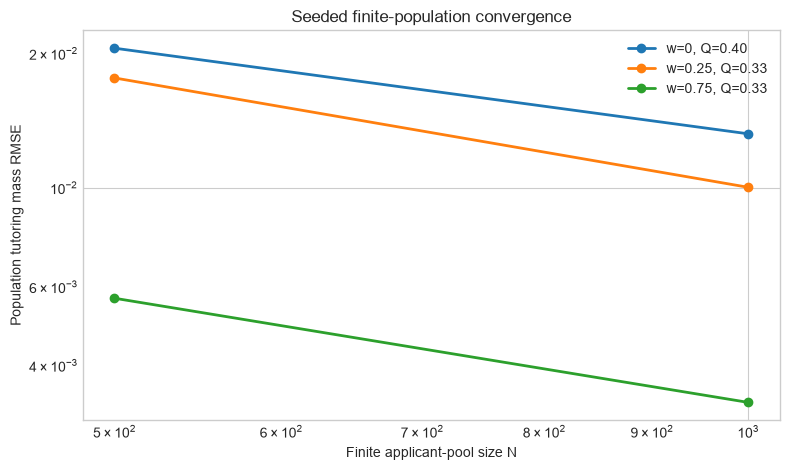

In [9]:
figure, axis = plt.subplots(figsize=(8, 4.8))
for weight, quota in ((0.0, 0.40), (0.25, 0.33), (0.75, 0.33)):
    validation = validation_results[weight, quota]
    sizes = [summary.population_size for summary in validation.population_summaries]
    errors = [
        summary.population_tutoring_mass.root_mean_squared_error
        for summary in validation.population_summaries
    ]
    axis.loglog(
        sizes, errors, marker='o', linewidth=2,
        label=f'w={weight:g}, Q={quota:.2f}',
    )
axis.set(
    xlabel='Finite applicant-pool size N',
    ylabel='Population tutoring mass RMSE',
    title='Seeded finite-population convergence',
)
axis.legend()
figure.tight_layout()
plt.show()


## Reproduction checklist

- Nested recovery evaluated before the $w>0$ exhibits.
- Every isolated equilibrium tabulated with regime and stability.
- Selected used only for exhibits and validation.
- First-class metrics remain distinct.
- Seed and $N=(500,1000)$ visible.
- Re-running from the repository root regenerates all values from tested public interfaces.
